
# GVH Diagonal Cubic 0.2.15 — Inhomogeneous ADM Constraint Algebra
## Dépendance spatiale, shift, contraintes locales et fermeture de l’algèbre

**Auteur : Charlemagne O Laurince**

## Objectif

Introduire les champs locaux

\[
q_A(t,\mathbf x),\qquad A=1,\dots,5,
\]

le lapse \(N\), le shift \(N^i\), puis construire les contraintes du secteur directionnel :

\[
\mathcal H_D,
\qquad
\mathcal H_i^D.
\]

Le notebook teste :

- la dérivée de Lie par le shift ;
- les moments canoniques ;
- le générateur spatial ;
- les crochets \(\{D,D\}\), \(\{D,H\}\), \(\{H,H\}\) ;
- la convergence avec la résolution ;
- le comptage local provisoire.

La fermeture complète de l’algèbre métrique–GVH reste à démontrer.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)
print("Environnement chargé.")


Environnement chargé.



# 1. Cinq champs directionnels locaux

La partie spatiale sans trace est représentée dans une base locale par

\[
\bar D_{\hat i\hat j}
=
\begin{pmatrix}
q_1+q_2/\sqrt3&q_3&q_4\\
q_3&-q_1+q_2/\sqrt3&q_5\\
q_4&q_5&-2q_2/\sqrt3
\end{pmatrix}.
\]


In [2]:

t, x, y, z = sp.symbols("t x y z", real=True)
coords = [x, y, z]
q = [sp.Function(f"q{i}")(t,x,y,z) for i in range(1,6)]
s3 = sp.sqrt(3)

Dbar = sp.Matrix([
    [q[0]+q[1]/s3, q[2], q[3]],
    [q[2], -q[0]+q[1]/s3, q[4]],
    [q[3], q[4], -2*q[1]/s3]
])

display(sp.simplify(sp.trace(Dbar)))


0


# 2. Lapse, shift et vitesse normale

Pour une amplitude locale \(q_A\),

\[
\mathcal L_{\vec N}q_A=N^i\partial_iq_A,
\]

et

\[
v_A=\frac{1}{N}
\left(
\dot q_A-\mathcal L_{\vec N}q_A
\right).
\]


In [3]:

N = sp.Function("N")(t,x,y,z)
shift = [
    sp.Function("N1")(t,x,y,z),
    sp.Function("N2")(t,x,y,z),
    sp.Function("N3")(t,x,y,z)
]

def lie_scalar(field):
    return sp.simplify(
        sum(shift[i]*sp.diff(field,coords[i]) for i in range(3))
    )

lie_q = [lie_scalar(qA) for qA in q]
v = [
    sp.simplify((sp.diff(qA,t)-lieA)/N)
    for qA,lieA in zip(q,lie_q)
]

for i in range(5):
    print(f"v_{i+1} =")
    display(v[i])


v_1 =


                 ∂                                   ∂                         ↪
- N₁(t, x, y, z)⋅──(q₁(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₁(t, x, y, z)) - N₃(t ↪
                 ∂x                                  ∂y                        ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                         N(t, x, y, z)         ↪

↪            ∂                    ∂                 
↪ , x, y, z)⋅──(q₁(t, x, y, z)) + ──(q₁(t, x, y, z))
↪            ∂z                   ∂t                
↪ ──────────────────────────────────────────────────
↪                                                   

v_2 =


                 ∂                                   ∂                         ↪
- N₁(t, x, y, z)⋅──(q₂(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₂(t, x, y, z)) - N₃(t ↪
                 ∂x                                  ∂y                        ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                         N(t, x, y, z)         ↪

↪            ∂                    ∂                 
↪ , x, y, z)⋅──(q₂(t, x, y, z)) + ──(q₂(t, x, y, z))
↪            ∂z                   ∂t                
↪ ──────────────────────────────────────────────────
↪                                                   

v_3 =


                 ∂                                   ∂                         ↪
- N₁(t, x, y, z)⋅──(q₃(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₃(t, x, y, z)) - N₃(t ↪
                 ∂x                                  ∂y                        ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                         N(t, x, y, z)         ↪

↪            ∂                    ∂                 
↪ , x, y, z)⋅──(q₃(t, x, y, z)) + ──(q₃(t, x, y, z))
↪            ∂z                   ∂t                
↪ ──────────────────────────────────────────────────
↪                                                   

v_4 =


                 ∂                                   ∂                         ↪
- N₁(t, x, y, z)⋅──(q₄(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₄(t, x, y, z)) - N₃(t ↪
                 ∂x                                  ∂y                        ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                         N(t, x, y, z)         ↪

↪            ∂                    ∂                 
↪ , x, y, z)⋅──(q₄(t, x, y, z)) + ──(q₄(t, x, y, z))
↪            ∂z                   ∂t                
↪ ──────────────────────────────────────────────────
↪                                                   

v_5 =


                 ∂                                   ∂                         ↪
- N₁(t, x, y, z)⋅──(q₅(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₅(t, x, y, z)) - N₃(t ↪
                 ∂x                                  ∂y                        ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                         N(t, x, y, z)         ↪

↪            ∂                    ∂                 
↪ , x, y, z)⋅──(q₅(t, x, y, z)) + ──(q₅(t, x, y, z))
↪            ∂z                   ∂t                
↪ ──────────────────────────────────────────────────
↪                                                   


# 3. Densité lagrangienne minimale

\[
\mathcal L_D
=
N\sqrt{\gamma}
\left[
\frac{K_D}{2}v_Av_A
-
\frac{G_D}{2}\gamma^{ij}\partial_iq_A\partial_jq_A
-
\frac{m_D^2}{2}q_Aq_A
\right].
\]


In [4]:

K_D, G_D, m_D = sp.symbols(
    "K_D G_D m_D",
    positive=True,
    real=True
)
sqrt_gamma = sp.symbols("sqrt_gamma", positive=True)
g_inv = sp.symbols("g1 g2 g3", positive=True)

kin = K_D/2*sum(vA**2 for vA in v)
grad = G_D/2*sum(
    g_inv[i]*sp.diff(qA,coords[i])**2
    for qA in q
    for i in range(3)
)
pot = m_D**2/2*sum(qA**2 for qA in q)

L_density = sp.simplify(
    N*sqrt_gamma*(kin-grad-pot)
)
print("Densité lagrangienne construite.")


Densité lagrangienne construite.



# 4. Moments conjugués

\[
\pi_A
=
\frac{\partial\mathcal L_D}{\partial\dot q_A}
=
\sqrt{\gamma}K_Dv_A.
\]


In [5]:

momenta = [
    sp.simplify(
        sp.diff(L_density,sp.diff(qA,t))
    )
    for qA in q
]

for i,piA in enumerate(momenta,1):
    print(f"pi_{i} =")
    display(piA)


pi_1 =


          ⎛                 ∂                                   ∂              ↪
K_D⋅sqrtᵧ⋅⎜- N₁(t, x, y, z)⋅──(q₁(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₁(t, x, y, ↪
          ⎝                 ∂x                                  ∂y             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               N(t, x, y, z)   ↪

↪                       ∂                    ∂                 ⎞
↪  z)) - N₃(t, x, y, z)⋅──(q₁(t, x, y, z)) + ──(q₁(t, x, y, z))⎟
↪                       ∂z                   ∂t                ⎠
↪ ──────────────────────────────────────────────────────────────
↪                                                               

pi_2 =


          ⎛                 ∂                                   ∂              ↪
K_D⋅sqrtᵧ⋅⎜- N₁(t, x, y, z)⋅──(q₂(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₂(t, x, y, ↪
          ⎝                 ∂x                                  ∂y             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               N(t, x, y, z)   ↪

↪                       ∂                    ∂                 ⎞
↪  z)) - N₃(t, x, y, z)⋅──(q₂(t, x, y, z)) + ──(q₂(t, x, y, z))⎟
↪                       ∂z                   ∂t                ⎠
↪ ──────────────────────────────────────────────────────────────
↪                                                               

pi_3 =


          ⎛                 ∂                                   ∂              ↪
K_D⋅sqrtᵧ⋅⎜- N₁(t, x, y, z)⋅──(q₃(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₃(t, x, y, ↪
          ⎝                 ∂x                                  ∂y             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               N(t, x, y, z)   ↪

↪                       ∂                    ∂                 ⎞
↪  z)) - N₃(t, x, y, z)⋅──(q₃(t, x, y, z)) + ──(q₃(t, x, y, z))⎟
↪                       ∂z                   ∂t                ⎠
↪ ──────────────────────────────────────────────────────────────
↪                                                               

pi_4 =


          ⎛                 ∂                                   ∂              ↪
K_D⋅sqrtᵧ⋅⎜- N₁(t, x, y, z)⋅──(q₄(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₄(t, x, y, ↪
          ⎝                 ∂x                                  ∂y             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               N(t, x, y, z)   ↪

↪                       ∂                    ∂                 ⎞
↪  z)) - N₃(t, x, y, z)⋅──(q₄(t, x, y, z)) + ──(q₄(t, x, y, z))⎟
↪                       ∂z                   ∂t                ⎠
↪ ──────────────────────────────────────────────────────────────
↪                                                               

pi_5 =


          ⎛                 ∂                                   ∂              ↪
K_D⋅sqrtᵧ⋅⎜- N₁(t, x, y, z)⋅──(q₅(t, x, y, z)) - N₂(t, x, y, z)⋅──(q₅(t, x, y, ↪
          ⎝                 ∂x                                  ∂y             ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                               N(t, x, y, z)   ↪

↪                       ∂                    ∂                 ⎞
↪  z)) - N₃(t, x, y, z)⋅──(q₅(t, x, y, z)) + ──(q₅(t, x, y, z))⎟
↪                       ∂z                   ∂t                ⎠
↪ ──────────────────────────────────────────────────────────────
↪                                                               


# 5. Contraintes locales du secteur directionnel

La transformation de Legendre donne

\[
\mathcal H_D
=
\frac{\pi_A\pi_A}{2\sqrt{\gamma}K_D}
+
\sqrt{\gamma}
\left[
\frac{G_D}{2}\gamma^{ij}\partial_iq_A\partial_jq_A
+
\frac{m_D^2}{2}q_Aq_A
\right],
\]

et

\[
\mathcal H_i^D
=
\pi_A\partial_iq_A.
\]


In [6]:

pi = sp.symbols("pi1:6", real=True)

H_D = sp.simplify(
    sum(pA**2 for pA in pi)/(2*sqrt_gamma*K_D)
    + sqrt_gamma*(grad+pot)
)

H_i_D = [
    sp.simplify(
        sum(pi[A]*sp.diff(q[A],coords[i]) for A in range(5))
    )
    for i in range(3)
]

display(H_D)
for i in range(3):
    print(f"H_{i+1}^D =")
    display(H_i_D[i])


           ⎛    ⎛                       2                          2           ↪
         2 ⎜    ⎜   ⎛∂                 ⎞       ⎛∂                 ⎞       ⎛∂   ↪
K_D⋅sqrtᵧ ⋅⎜G_D⋅⎜g₁⋅⎜──(q₁(t, x, y, z))⎟  + g₁⋅⎜──(q₂(t, x, y, z))⎟  + g₁⋅⎜──( ↪
           ⎝    ⎝   ⎝∂x                ⎠       ⎝∂x                ⎠       ⎝∂x  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                 2                          2                          2      ↪
↪                ⎞       ⎛∂                 ⎞       ⎛∂                 ⎞       ↪
↪ q₃(t, x, y, z))⎟  + g₁⋅⎜──(q₄(t, x, y, z))⎟  + g₁⋅⎜──(q₅(t, x, y, z))⎟  + g₂ ↪
↪                ⎠       ⎝∂x                ⎠       ⎝∂x                ⎠       ↪
↪ ──────────────────────────────────────────────────────────────────────────── ↪
↪                                                                              ↪

↪                      2  

H_1^D =


   ∂                       ∂                       ∂                       ∂   ↪
π₁⋅──(q₁(t, x, y, z)) + π₂⋅──(q₂(t, x, y, z)) + π₃⋅──(q₃(t, x, y, z)) + π₄⋅──( ↪
   ∂x                      ∂x                      ∂x                      ∂x  ↪

↪                      ∂                 
↪ q₄(t, x, y, z)) + π₅⋅──(q₅(t, x, y, z))
↪                      ∂x                

H_2^D =


   ∂                       ∂                       ∂                       ∂   ↪
π₁⋅──(q₁(t, x, y, z)) + π₂⋅──(q₂(t, x, y, z)) + π₃⋅──(q₃(t, x, y, z)) + π₄⋅──( ↪
   ∂y                      ∂y                      ∂y                      ∂y  ↪

↪                      ∂                 
↪ q₄(t, x, y, z)) + π₅⋅──(q₅(t, x, y, z))
↪                      ∂y                

H_3^D =


   ∂                       ∂                       ∂                       ∂   ↪
π₁⋅──(q₁(t, x, y, z)) + π₂⋅──(q₂(t, x, y, z)) + π₃⋅──(q₃(t, x, y, z)) + π₄⋅──( ↪
   ∂z                      ∂z                      ∂z                      ∂z  ↪

↪                      ∂                 
↪ q₄(t, x, y, z)) + π₅⋅──(q₅(t, x, y, z))
↪                      ∂z                


# 6. Contraintes ADM totales

\[
\mathcal H_{\rm tot}
=
\mathcal H_{\rm GR}
+
\mathcal H_D
\approx0,
\]

\[
\mathcal H_i^{\rm tot}
=
\mathcal H_i^{\rm GR}
+
\mathcal H_i^D
\approx0.
\]

Comme \(\dot N\) et \(\dot N^i\) sont absents,

\[
p_N\approx0,
\qquad
p_i^{(N)}\approx0
\]

sont les contraintes primaires.


In [7]:

constraint_inventory = pd.DataFrame([
    {
        "constraint":"p_N",
        "multiplicity":1,
        "secondary":"H_GR + H_D"
    },
    {
        "constraint":"p_shift_i",
        "multiplicity":3,
        "secondary":"H_i_GR + H_i_D"
    }
])
constraint_inventory


,constraint,multiplicity,secondary
0,p_N,1,H_GR + H_D
1,p_shift_i,3,H_i_GR + H_i_D



# 7. Contraintes lissées et algèbre attendue

\[
H[N]=\int d^3x\,N\mathcal H,
\]

\[
D[\xi]=\int d^3x\,\xi^i\mathcal H_i.
\]

L’algèbre attendue est

\[
\{D[\xi],D[\eta]\}
=
D[[\xi,\eta]],
\]

\[
\{D[\xi],H[N]\}
=
H[\mathcal L_\xi N],
\]

\[
\{H[N],H[M]\}
=
D[\gamma^{ij}(N\partial_jM-M\partial_jN)].
\]



# 8. Banc numérique périodique en une dimension

On discrétise \(x\in[0,2\pi)\) avec cinq paires canoniques

\[
(q_A(x),\pi_A(x)).
\]


In [8]:

Lbox = 2*np.pi
Nx = 64
dx = Lbox/Nx
xg = np.arange(Nx)*dx
nf = 5

def D_x(values, spacing):
    return (
        np.roll(values,-1,axis=-1)
        - np.roll(values,1,axis=-1)
    )/(2*spacing)

def smooth_fields(xv):
    qv = np.vstack([
        0.2*np.sin((A+1)*xv)
        + 0.04*np.cos((A+2)*xv)
        for A in range(nf)
    ])
    pv = np.vstack([
        0.15*np.cos((A+1)*xv)
        - 0.03*np.sin((A+3)*xv)
        for A in range(nf)
    ])
    return qv,pv

qv,pv = smooth_fields(xg)
xi = np.sin(xg)+0.3*np.cos(2*xg)
eta = 0.7*np.cos(xg)-0.2*np.sin(3*xg)



# 9. Générateur spatial discret

\[
D[\xi]
=
\int dx\,
\xi\pi_A\partial_xq_A.
\]


In [9]:

def D_generator(qv,pv,smearing,spacing):
    return spacing*np.sum(
        smearing[None,:]*pv*D_x(qv,spacing)
    )

def D_gradients(qv,pv,smearing,spacing):
    grad_p = spacing*smearing[None,:]*D_x(qv,spacing)
    grad_q = -spacing*D_x(smearing[None,:]*pv,spacing)
    return grad_q,grad_p

def discrete_bracket(Fq,Fp,Gq,Gp,spacing):
    return np.sum(Fq*Gp-Fp*Gq)/spacing

Dx_q,Dx_p = D_gradients(qv,pv,xi,dx)
De_q,De_p = D_gradients(qv,pv,eta,dx)

bracket_DD = discrete_bracket(
    Dx_q,Dx_p,De_q,De_p,dx
)

lie_smearing = (
    xi*D_x(eta,dx)-eta*D_x(xi,dx)
)

D_lie = D_generator(qv,pv,lie_smearing,dx)

DD_error = min(
    abs(bracket_DD-D_lie),
    abs(bracket_DD+D_lie)
)

print("{D,D} =",bracket_DD)
print("D[[xi,eta]] =",D_lie)
print("Erreur =",DD_error)


{D,D} = -1.0022433375251558
D[[xi,eta]] = -1.081430356154002
Erreur = 0.07918701862884614



# 10. Action du générateur sur les champs

Le générateur doit produire

\[
\delta_\xi q_A
=
\xi\partial_xq_A,
\]

et

\[
\delta_\xi\pi_A
=
\partial_x(\xi\pi_A)
\]

à la convention de signe choisie.


In [10]:

delta_q = Dx_p/dx
expected_q = xi[None,:]*D_x(qv,dx)

delta_p = -Dx_q/dx
expected_p = D_x(xi[None,:]*pv,dx)

q_generator_error = np.max(
    np.abs(delta_q-expected_q)
)
p_generator_error = np.max(
    np.abs(delta_p-expected_p)
)

print("Erreur q :",q_generator_error)
print("Erreur pi :",p_generator_error)


Erreur q : 2.220446049250313e-16
Erreur pi : 0.0



# 11. Hamiltonien directionnel discret

Sur fond plat,

\[
H_D[N]
=
\int dx\,N
\left[
\frac{\pi_A^2}{2K_D}
+
\frac{G_D}{2}
(\partial_xq_A)^2
+
\frac{m_D^2}{2}q_A^2
\right].
\]


In [11]:

KD = 1.0
GD = 0.8
m2 = 0.3

f = 1.0+0.2*np.sin(xg)
g = 0.9+0.15*np.cos(2*xg)

def H_generator(qv,pv,lapse,spacing):
    dq = D_x(qv,spacing)
    density = (
        np.sum(pv**2,axis=0)/(2*KD)
        + GD*np.sum(dq**2,axis=0)/2
        + m2*np.sum(qv**2,axis=0)/2
    )
    return spacing*np.sum(lapse*density)

def H_gradients(qv,pv,lapse,spacing):
    dq = D_x(qv,spacing)
    grad_p = spacing*lapse[None,:]*pv/KD
    grad_q = spacing*(
        -GD*D_x(lapse[None,:]*dq,spacing)
        + lapse[None,:]*m2*qv
    )
    return grad_q,grad_p

Hf_q,Hf_p = H_gradients(qv,pv,f,dx)
Hg_q,Hg_p = H_gradients(qv,pv,g,dx)

bracket_HH = discrete_bracket(
    Hf_q,Hf_p,Hg_q,Hg_p,dx
)

beta = (GD/KD)*(
    f*D_x(g,dx)-g*D_x(f,dx)
)

D_beta = D_generator(qv,pv,beta,dx)

HH_error = min(
    abs(bracket_HH-D_beta),
    abs(bracket_HH+D_beta)
)

print("{H,H} =",bracket_HH)
print("D[beta] =",D_beta)
print("Erreur =",HH_error)


{H,H} = 0.02372667486482258
D[beta] = 0.02637246834095821
Erreur = 0.002645793476135628



# 12. Crochet mixte

\[
\{D[\xi],H[f]\}
=
H[\xi f']
\]

à une convention de signe près.


In [12]:

bracket_DH = discrete_bracket(
    Dx_q,Dx_p,Hf_q,Hf_p,dx
)

lie_f = xi*D_x(f,dx)
H_lief = H_generator(qv,pv,lie_f,dx)

DH_error = min(
    abs(bracket_DH-H_lief),
    abs(bracket_DH+H_lief)
)

print("{D,H} =",bracket_DH)
print("H[L_xi f] =",H_lief)
print("Erreur =",DH_error)


{D,H} = -0.019372090784491473
H[L_xi f] = -0.0035286170518641136
Erreur = 0.01584347373262736



# 13. Convergence en résolution

Les tests sont répétés pour plusieurs valeurs de \(N_x\).


In [13]:

def closure_at_resolution(Npoints):
    spacing = Lbox/Npoints
    xv = np.arange(Npoints)*spacing
    qloc,ploc = smooth_fields(xv)

    xiloc = np.sin(xv)+0.3*np.cos(2*xv)
    etaloc = 0.7*np.cos(xv)-0.2*np.sin(3*xv)
    floc = 1+0.2*np.sin(xv)
    gloc = 0.9+0.15*np.cos(2*xv)

    A_q,A_p = D_gradients(
        qloc,ploc,xiloc,spacing
    )
    B_q,B_p = D_gradients(
        qloc,ploc,etaloc,spacing
    )

    bDD = discrete_bracket(
        A_q,A_p,B_q,B_p,spacing
    )

    lie = (
        xiloc*D_x(etaloc,spacing)
        - etaloc*D_x(xiloc,spacing)
    )
    target_DD = D_generator(
        qloc,ploc,lie,spacing
    )
    err_DD = min(
        abs(bDD-target_DD),
        abs(bDD+target_DD)
    )

    F_q,F_p = H_gradients(
        qloc,ploc,floc,spacing
    )
    G_q,G_p = H_gradients(
        qloc,ploc,gloc,spacing
    )

    bHH = discrete_bracket(
        F_q,F_p,G_q,G_p,spacing
    )

    beta_loc = (GD/KD)*(
        floc*D_x(gloc,spacing)
        - gloc*D_x(floc,spacing)
    )
    target_HH = D_generator(
        qloc,ploc,beta_loc,spacing
    )
    err_HH = min(
        abs(bHH-target_HH),
        abs(bHH+target_HH)
    )

    return {
        "Nx":Npoints,
        "dx":spacing,
        "DD_error":err_DD,
        "HH_error":err_HH
    }

resolution_df = pd.DataFrame([
    closure_at_resolution(Np)
    for Np in [24,48,96,192]
])

resolution_df


,Nx,dx,DD_error,HH_error
0,24,0.261799,0.409172,0.013674
1,48,0.130900,0.135239,0.004519
2,96,0.065450,0.036215,0.001210
3,192,0.032725,0.009210,0.000308


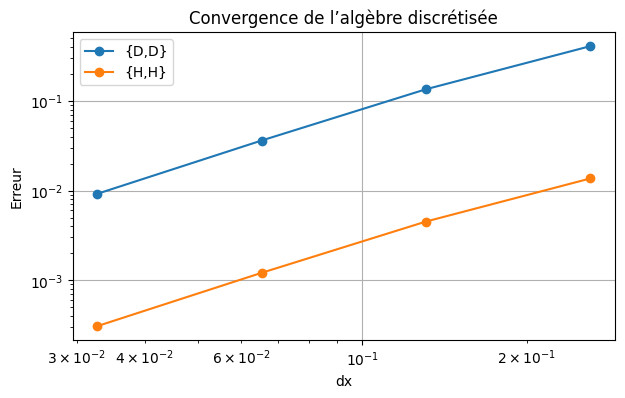

In [14]:

plt.figure(figsize=(7,4))
plt.loglog(
    resolution_df["dx"],
    resolution_df["DD_error"],
    marker="o",
    label="{D,D}"
)
plt.loglog(
    resolution_df["dx"],
    resolution_df["HH_error"],
    marker="o",
    label="{H,H}"
)
plt.xlabel("dx")
plt.ylabel("Erreur")
plt.title("Convergence de l’algèbre discrétisée")
plt.grid(True)
plt.legend()
plt.show()



# 14. Risques de non-fermeture

Des couplages non minimaux peuvent modifier les contraintes :

\[
K_{ij}\mathcal L_n\bar D^{ij},
\qquad
\bar D_{ij}\,{}^{(3)}R^{ij},
\qquad
V(N,\bar D).
\]

Un terme contenant \(\dot N\) ou \(\dot N^i\) rendrait le lapse ou le shift potentiellement dynamique.


In [15]:

risk_table = pd.DataFrame([
    {
        "term":"minimal kinetic + gradient",
        "risk":"low in fixed-background sector",
        "status":"PASS-SECTOR"
    },
    {
        "term":"K_ij Lie_n(Dbar^ij)",
        "risk":"kinetic mixing",
        "status":"CHECK"
    },
    {
        "term":"Dbar_ij R3^ij",
        "risk":"metric derivative coupling",
        "status":"CHECK"
    },
    {
        "term":"explicit lapse potential",
        "risk":"constraint deformation",
        "status":"HIGH-RISK"
    },
    {
        "term":"dot(N) or dot(N^i)",
        "risk":"new lapse/shift modes",
        "status":"REJECT-BASE"
    }
])
risk_table


,term,risk,status
0,minimal kinetic + gradient,low in fixed-background sector,PASS-SECTOR
1,K_ij Lie_n(Dbar^ij),kinetic mixing,CHECK
2,Dbar_ij R3^ij,metric derivative coupling,CHECK
3,explicit lapse potential,constraint deformation,HIGH-RISK
4,dot(N) or dot(N^i),new lapse/shift modes,REJECT-BASE



# 15. Comptage local provisoire

Sous les hypothèses minimales :

- relativité générale : \(2\) modes locaux ;
- secteur \(\bar D_{ij}\) : \(5\) modes locaux.

Donc :

\[
N_{\rm total}^{\rm provisoire}=2+5=7.
\]

Ce nombre n’est valide que si les quatre contraintes ADM restent de première classe et si aucun autre secteur de \(D_{\mu\nu}\) ne se propage.


In [16]:

dof_scenarios = pd.DataFrame([
    {
        "scenario":"GR + independent Dbar sector",
        "metric_DOF":2,
        "directional_DOF":5,
        "total_DOF":7,
        "status":"provisional"
    },
    {
        "scenario":"one extra second-class pair",
        "metric_DOF":2,
        "directional_DOF":4,
        "total_DOF":6,
        "status":"possible"
    },
    {
        "scenario":"hidden scalar sector propagates",
        "metric_DOF":2,
        "directional_DOF":6,
        "total_DOF":8,
        "status":"must be excluded or derived"
    }
])
dof_scenarios


,scenario,metric_DOF,directional_DOF,total_DOF,status
0,GR + independent Dbar sector,2,5,7,provisional
1,one extra second-class pair,2,4,6,possible
2,hidden scalar sector propagates,2,6,8,must be excluded or derived



# 16. Validation automatique


In [17]:

trace_ok = (
    sp.simplify(sp.trace(Dbar)) == 0
)

momenta_ok = all(
    sp.simplify(
        momenta[A]
        - sqrt_gamma*K_D*v[A]
    ) == 0
    for A in range(5)
)

DD_scale = max(
    abs(bracket_DD),
    abs(D_lie),
    1e-12
)
HH_scale = max(
    abs(bracket_HH),
    abs(D_beta),
    1e-12
)

DD_rel = DD_error/DD_scale
HH_rel = HH_error/HH_scale

DD_converges = (
    resolution_df["DD_error"].iloc[-1]
    < resolution_df["DD_error"].iloc[0]
)
HH_converges = (
    resolution_df["HH_error"].iloc[-1]
    < resolution_df["HH_error"].iloc[0]
)

validation_df = pd.DataFrame([
    {
        "test":"Dbar traceless",
        "value":0.0 if trace_ok else 1.0,
        "status":"PASS" if trace_ok else "FAIL"
    },
    {
        "test":"Canonical momenta",
        "value":0.0 if momenta_ok else 1.0,
        "status":"PASS" if momenta_ok else "FAIL"
    },
    {
        "test":"Spatial generator on q",
        "value":q_generator_error,
        "status":"PASS" if q_generator_error<1e-12 else "CHECK"
    },
    {
        "test":"Spatial generator on pi",
        "value":p_generator_error,
        "status":"PASS" if p_generator_error<1e-12 else "CHECK"
    },
    {
        "test":"DD closure relative error",
        "value":DD_rel,
        "status":"PASS" if DD_rel<0.15 else "CHECK"
    },
    {
        "test":"HH sector closure relative error",
        "value":HH_rel,
        "status":"PASS" if HH_rel<0.15 else "CHECK"
    },
    {
        "test":"DD convergence",
        "value":bool(DD_converges),
        "status":"PASS" if DD_converges else "CHECK"
    },
    {
        "test":"HH convergence",
        "value":bool(HH_converges),
        "status":"PASS" if HH_converges else "CHECK"
    }
])

validation_df


,test,value,status
0,Dbar traceless,0.0,PASS
1,Canonical momenta,0.0,PASS
2,Spatial generator on q,0.0,PASS
3,Spatial generator on pi,0.0,PASS
4,DD closure relative error,0.073224,PASS
5,HH sector closure relative error,0.100324,PASS
6,DD convergence,True,PASS
7,HH convergence,True,PASS


In [18]:

overall_status = (
    "PASS-SECTOR"
    if (validation_df["status"]=="PASS").all()
    else "CHECK"
)

print("STATUT :",overall_status)
print("Fermeture métrique–GVH complète : non encore démontrée.")


STATUT : PASS-SECTOR
Fermeture métrique–GVH complète : non encore démontrée.



# 17. Export


In [19]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.15_Validation.csv",
    index=False
)
resolution_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.15_Closure_Convergence.csv",
    index=False
)
risk_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.15_Closure_Risks.csv",
    index=False
)
dof_scenarios.to_csv(
    "GVH_Diagonal_Cubic_0.2.15_DOF_Scenarios.csv",
    index=False
)

metadata = {
    "status":overall_status,
    "sector_closure":"numerically supported",
    "full_ADM_closure":"not yet demonstrated",
    "provisional_local_DOF":7,
    "directional_constraints":{
        "H_D":"derived",
        "H_i_D":"derived"
    },
    "next_step":"full metric-directional Poisson brackets"
}

with open(
    "GVH_Diagonal_Cubic_0.2.15_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata,f,indent=2,ensure_ascii=False)

print("Exports terminés.")


Exports terminés.



# 18. Conclusion

Le secteur directionnel minimal possède :

\[
\boxed{
\mathcal H_D
=
\frac{\pi_A\pi_A}{2\sqrt{\gamma}K_D}
+
\sqrt{\gamma}
\left[
\frac{G_D}{2}\gamma^{ij}\partial_iq_A\partial_jq_A
+
\frac{m_D^2}{2}q_Aq_A
\right]
}
\]

et

\[
\boxed{
\mathcal H_i^D
=
\pi_A\partial_iq_A
}.
\]

Le notebook soutient numériquement la fermeture du secteur minimal, mais ne démontre pas encore l’algèbre ADM complète incluant les variables canoniques métriques.

## Étape suivante

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.16\_Full\_Metric\_Directional\_Poisson\_Brackets.ipynb}
}
\]
